# Machine Learning - Homework 2: Part 1

## 1. Dataset Generation

The dataset that will be used throughout this part is already created and split for you. Do not change any part of the code below.

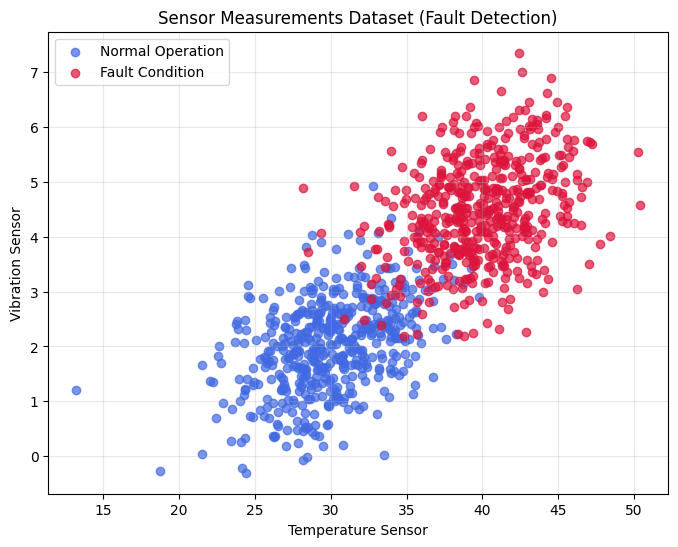

In [2]:
#############################
# DO NOT CHANGE THIS PART
#############################

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(55)

n_per_class = 500

# Normal machine operation
normal = np.random.multivariate_normal(
    mean=[30, 2],
    cov=[[12, 1.5],
         [1.5, 0.8]],
    size=n_per_class
)

# Fault condition
fault = np.random.multivariate_normal(
    mean=[40, 4.5],
    cov=[[12, 1.0],
         [1.0, 0.8]],
    size=n_per_class
)

X = np.vstack([normal, fault])
y = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])

#############################
# DO NOT CHANGE THIS PART
#############################


# Visualization

plt.figure(figsize=(8,6))

plt.scatter(
    normal[:,0], normal[:,1],
    color="royalblue",
    label="Normal Operation",
    alpha=0.7
)

plt.scatter(
    fault[:,0], fault[:,1],
    color="crimson",
    label="Fault Condition",
    alpha=0.7
)

plt.xlabel("Temperature Sensor")
plt.ylabel("Vibration Sensor")
plt.title("Sensor Measurements Dataset (Fault Detection)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [3]:


X_bias = np.hstack([np.ones((X.shape[0], 1)), X])

# Initialize parameters
w = np.zeros(X_bias.shape[1])   # [w0, w1, w2]
eta = 0.1
T = 10

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(y_true, y_pred):
    eps = 1e-12  # avoid log(0)
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Gradient descent for exactly 10 iterations
for _ in range(T):
    z = X_bias @ w
    y_hat = sigmoid(z)
    grad = (X_bias.T @ (y_hat - y)) / len(y)
    w = w - eta * grad

# Final predictions
z_final = X_bias @ w
y_hat_final = sigmoid(z_final)
y_pred_final = (y_hat_final >= 0.5).astype(int)

# Metrics
final_loss = compute_loss(y, y_hat_final)
classification_error = np.mean(y_pred_final != y)

# Results
print(f"Final w0: {w[0]:.4f}")
print(f"Final w1: {w[1]:.4f}")
print(f"Final w2: {w[2]:.4f}")
print(f"Final loss J(w^10): {final_loss:.4f}")
print(f"Classification error rate: {classification_error:.4f}")

Final w0: -0.0500
Final w1: 0.7345
Final w2: 0.4524
Final loss J(w^10): 11.4262
Classification error rate: 0.5000


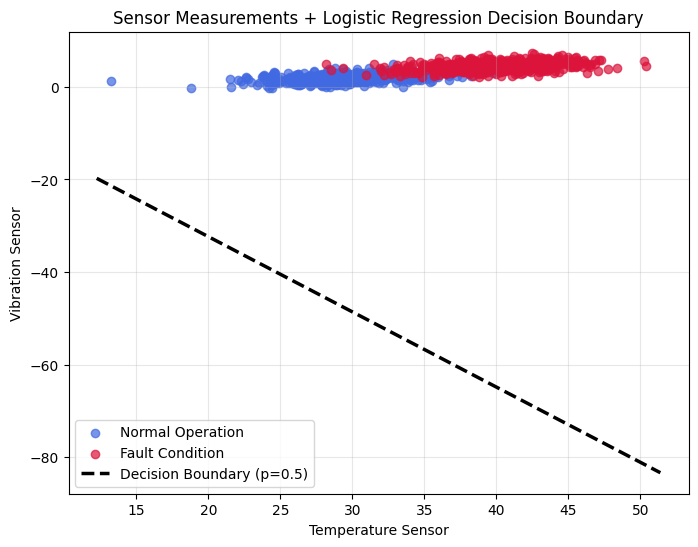

In [4]:
# Decision boundary'yi ayrı hücrede çiz (ilk hücreyi değiştirmeden)

# Eğer önceki hücrelerden geliyorsa:
# normal, fault, X, w değişkenleri tanımlı olmalı.

plt.figure(figsize=(8, 6))

# Orijinal scatter
plt.scatter(
    normal[:, 0], normal[:, 1],
    color="royalblue", label="Normal Operation", alpha=0.7
)
plt.scatter(
    fault[:, 0], fault[:, 1],
    color="crimson", label="Fault Condition", alpha=0.7
)

# Logistic regression decision boundary: w0 + w1*x + w2*y = 0
x_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300)

if abs(w[2]) > 1e-12:
    y_vals = -(w[0] + w[1] * x_vals) / w[2]
    plt.plot(x_vals, y_vals, "k--", linewidth=2.5, label="Decision Boundary (p=0.5)")
else:
    # Çok nadir: sınır neredeyse dikeyse
    x_vertical = -w[0] / w[1]
    plt.axvline(x=x_vertical, color="k", linestyle="--", linewidth=2.5, label="Decision Boundary (p=0.5)")

plt.xlabel("Temperature Sensor")
plt.ylabel("Vibration Sensor")
plt.title("Sensor Measurements + Logistic Regression Decision Boundary")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Machine Learning - Homework 2: Part 2

## 1. Dataset Generation

The dataset that will be used throughout this part is already created and split for you. Do not change any part of the code below.

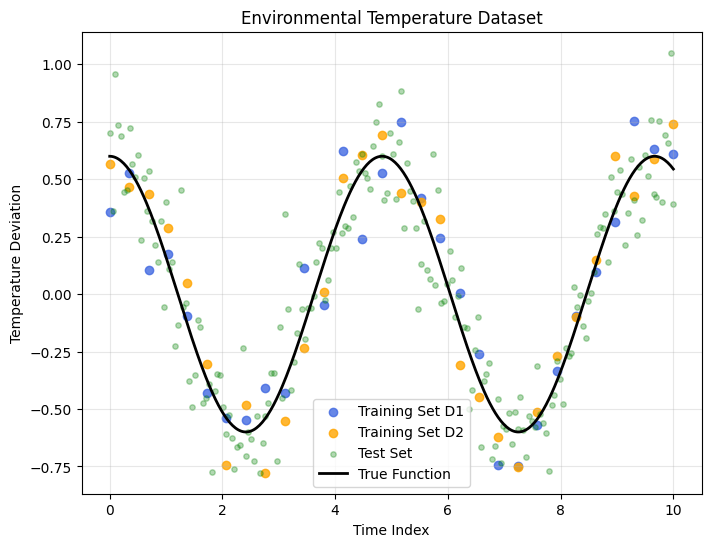

In [6]:
#############################
# DO NOT CHANGE THIS PART
#############################

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(55)

# Training dataset D1
x_train_d1 = np.linspace(0, 10, 30)
noise_d1 = np.random.normal(0, 0.15, size=x_train_d1.shape)
y_train_d1 = 0.6 * np.cos(1.3 * x_train_d1) + noise_d1


# Training dataset D2
x_train_d2 = np.linspace(0, 10, 30)
noise_d2 = np.random.normal(0, 0.15, size=x_train_d2.shape)
y_train_d2 = 0.6 * np.cos(1.3 * x_train_d2) + noise_d2


# Test dataset
x_test = np.linspace(0, 10, 200)
noise_test = np.random.normal(0, 0.15, size=x_test.shape)
y_test = 0.6 * np.cos(1.3 * x_test) + noise_test

#############################
# DO NOT CHANGE THIS PART
#############################


# True function (for visualization)
x_true = np.linspace(0, 10, 400)
y_true = 0.6 * np.cos(1.3 * x_true)


# Visualization

plt.figure(figsize=(8,6))

plt.scatter(
    x_train_d1, y_train_d1,
    color="royalblue",
    label="Training Set D1",
    alpha=0.8
)

plt.scatter(
    x_train_d2, y_train_d2,
    color="orange",
    label="Training Set D2",
    alpha=0.8
)

plt.scatter(
    x_test, y_test,
    color="green",
    label="Test Set",
    alpha=0.3,
    s=15
)

plt.plot(
    x_true, y_true,
    color="black",
    linewidth=2,
    label="True Function"
)

plt.xlabel("Time Index")
plt.ylabel("Temperature Deviation")
plt.title("Environmental Temperature Dataset")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

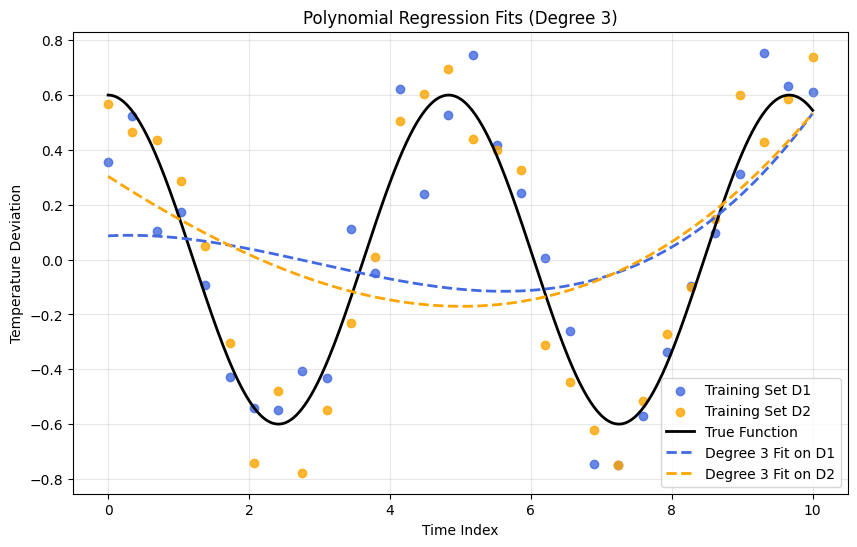

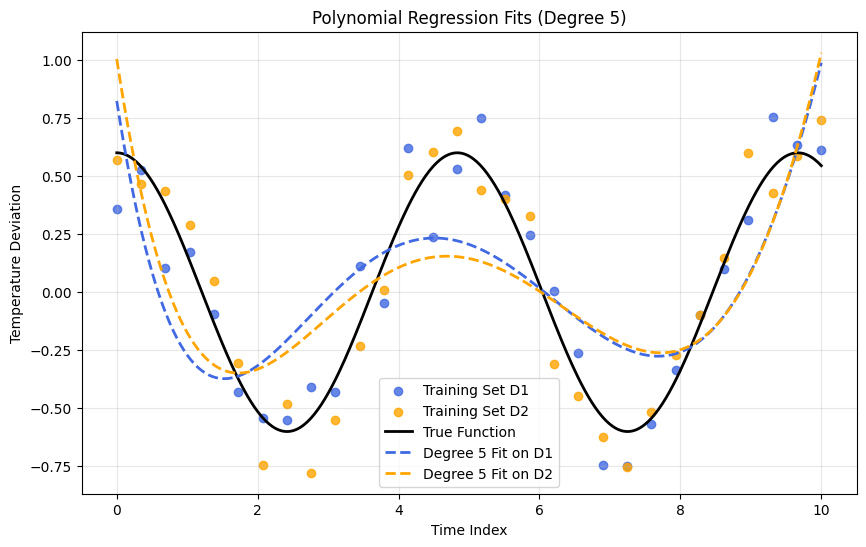

Test MSE (degree 3, D1): 0.1905
Test MSE (degree 3, D2): 0.1905
Test MSE (degree 5, D1): 0.0965
Test MSE (degree 5, D2): 0.0914


In [7]:
def design_matrix(x, degree):
    return np.vander(x, N=degree + 1, increasing=True)

def fit_polynomial_regression(x, y, degree):
    X = design_matrix(x, degree)
    w = np.linalg.solve(X.T @ X, X.T @ y)
    return w

def predict_polynomial(x, w):
    X = design_matrix(x, len(w) - 1)
    return X @ w

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# Fit models
w_d1_deg3 = fit_polynomial_regression(x_train_d1, y_train_d1, 3)
w_d2_deg3 = fit_polynomial_regression(x_train_d2, y_train_d2, 3)
w_d1_deg5 = fit_polynomial_regression(x_train_d1, y_train_d1, 5)
w_d2_deg5 = fit_polynomial_regression(x_train_d2, y_train_d2, 5)

# Predictions on test set
y_test_pred_d1_deg3 = predict_polynomial(x_test, w_d1_deg3)
y_test_pred_d2_deg3 = predict_polynomial(x_test, w_d2_deg3)
y_test_pred_d1_deg5 = predict_polynomial(x_test, w_d1_deg5)
y_test_pred_d2_deg5 = predict_polynomial(x_test, w_d2_deg5)

# Compute Test MSE values
mse_d1_deg3 = mse(y_test, y_test_pred_d1_deg3)
mse_d2_deg3 = mse(y_test, y_test_pred_d2_deg3)
mse_d1_deg5 = mse(y_test, y_test_pred_d1_deg5)
mse_d2_deg5 = mse(y_test, y_test_pred_d2_deg5)

# Smooth plotting grid
x_plot = np.linspace(0, 10, 400)
y_true_plot = 0.6 * np.cos(1.3 * x_plot)

y_plot_d1_deg3 = predict_polynomial(x_plot, w_d1_deg3)
y_plot_d2_deg3 = predict_polynomial(x_plot, w_d2_deg3)
y_plot_d1_deg5 = predict_polynomial(x_plot, w_d1_deg5)
y_plot_d2_deg5 = predict_polynomial(x_plot, w_d2_deg5)

# Figure 1: Degree 3
plt.figure(figsize=(10, 6))
plt.scatter(x_train_d1, y_train_d1, color="royalblue", alpha=0.8, label="Training Set D1")
plt.scatter(x_train_d2, y_train_d2, color="orange", alpha=0.8, label="Training Set D2")
plt.plot(x_plot, y_true_plot, color="black", linewidth=2, label="True Function")
plt.plot(x_plot, y_plot_d1_deg3, color="royalblue", linestyle="--", linewidth=2, label="Degree 3 Fit on D1")
plt.plot(x_plot, y_plot_d2_deg3, color="orange", linestyle="--", linewidth=2, label="Degree 3 Fit on D2")
plt.xlabel("Time Index")
plt.ylabel("Temperature Deviation")
plt.title("Polynomial Regression Fits (Degree 3)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Figure 2: Degree 5
plt.figure(figsize=(10, 6))
plt.scatter(x_train_d1, y_train_d1, color="royalblue", alpha=0.8, label="Training Set D1")
plt.scatter(x_train_d2, y_train_d2, color="orange", alpha=0.8, label="Training Set D2")
plt.plot(x_plot, y_true_plot, color="black", linewidth=2, label="True Function")
plt.plot(x_plot, y_plot_d1_deg5, color="royalblue", linestyle="--", linewidth=2, label="Degree 5 Fit on D1")
plt.plot(x_plot, y_plot_d2_deg5, color="orange", linestyle="--", linewidth=2, label="Degree 5 Fit on D2")
plt.xlabel("Time Index")
plt.ylabel("Temperature Deviation")
plt.title("Polynomial Regression Fits (Degree 5)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Print requested results
print(f"Test MSE (degree 3, D1): {mse_d1_deg3:.4f}")
print(f"Test MSE (degree 3, D2): {mse_d2_deg3:.4f}")
print(f"Test MSE (degree 5, D1): {mse_d1_deg5:.4f}")
print(f"Test MSE (degree 5, D2): {mse_d2_deg5:.4f}")